# Parallel Workflows with reducers and LLMs
- Problem Statment revolves around UPSC Essay evaluation
- Each essay undergoes 3 steps of checks 
    1. Coverage of thoughts
    2. Language usage
    3. Creativity
- Each of the categories is evaluated by different LLMs
- Each LLM will need to produce 2 outputs
    1. Textual feedback
    2. Score betwen 0-10
- Finally the final node will be the final evaulator. This must return
    1. Summarized feedback consisting the outputs of the 3 LLMs
    2. Average score
- Workflow
    - START -> 3 parallel Nodes(Coverage of thoughts, creativity, language useage) -> Final Evaluator -> END
- As the outputs of all the 3 parallel nodes will be updating the same state attributes i.e. 1 for textual feedback and the other for the score between 0-10
- To generate the summary the results of each LLM is important, thus we cannot update/overwrite the same state variables instead we will need to append/ concatinate with the same state variable. This can be attained by making use of reducers
- To ensure that each parallel LLM provides a score and a feedback a structured output must be provided


In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

In [20]:
model = ChatGroq(model = "qwen/qwen3-32b")

In [21]:
# Schema for the data - this ensures that the output from the LLM will be in the structured manner
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Feedback of the essay")
    score: int = Field(description="Score out of 10", ge=0,le=100)

In [22]:
structured_model = model.with_structured_output(EvaluationSchema)

### Example to test it out whether the output from the LLM will be structured or not

In [23]:
content = f"ChatGPT is a generative artificial intelligence chatbot developed by OpenAI. It was released in November 2022. It uses generative pre-trained transformers, such as GPT-5.2, to generate text, speech, and images in response to user prompts."
prompt = f"Evaluate the given content and give a feedback and a score between 0-10. The content is {content}"
structured_model.invoke(prompt)

EvaluationSchema(feedback="The content correctly identifies ChatGPT as a generative AI chatbot developed by OpenAI and its release date in November 2022. However, it incorrectly states that ChatGPT uses 'GPT-5.2,' which is not an officially released model as of October 2023 (the latest public model is GPT-4). This factual inaccuracy reduces the overall accuracy. The structure is clear, but the content lacks additional details about ChatGPT's capabilities or impact.", score=7)

# Defining the State

In [24]:
import operator
from typing import Annotated

class State(TypedDict):
    essay: str
    # Feedback state maintained for parallel nodes
    language_feedback: str
    coverage_feedback: str
    creativity_feedback: str

    # Overall feedback state attribute maintained by Evaluator
    overall_feedback: str

    # Common scores stateattribute maintained for parallel nodes
    individual_scores: Annotated[list[int], operator.add]

    # Avg score state attribute maintained by the Evaluator node
    avg_score: float

- Reducer function here is add thus the script for the same is -> individual_scores: Annotated[list[int], operator.add]
- This implies that if we have 3 parallel nodes return scores as [6], [8], [10] as seperate lists, then since the reducer is add it adds all the lists finally the individual_scores will be [6, 8, 10]

# Defining the functions

In [31]:
def check_creativity(state: State) -> State:
    prompt = f"Evaluate the creativeness of the essay: {state["essay"]} and give the feedback and a score between 0-10"

    response = structured_model.invoke(prompt)  

    return {
        "creativity_feedback": response.feedback,
        "individual_scores": [response.score] # Its a list of score so that reducer add will append all the scores from the LLM
    } 


def check_language(state: State) -> State:
    prompt = f"Evaluate the language useage of the essay: {state["essay"]} and give the feedback and a score between 0-10"

    response = structured_model.invoke(prompt)  

    return {
        "language_feedback": response.feedback,
        "individual_scores": [response.score] # Its a list of score so that reducer add will append all the scores from the LLM
    } 


def check_coverage(state: State) -> State:
    prompt = f"Evaluate the coverage of thoughts of the essay: {state["essay"]} and give the feedback and a score between 0-10"

    response = structured_model.invoke(prompt)  

    return {
        "coverage_feedback": response.feedback,
        "individual_scores": [response.score] # Its a list of score so that reducer add will append all the scores from the LLM
    } 
    

def evaluator(state: State) -> State:
    prompt = f"""Summarize the whole feedback. The feedbacks are
    1. {state["coverage_feedback"]}
    2. {state["creativity_feedback"]}
    3. {state["language_feedback"]}
    """

    response = model.invoke(prompt)  

    return {
        "overall_feedback": response,
        "average_score": sum(state["individual_scores"])/len(state["individual_scores"])
    } 
    

In [32]:
graph = StateGraph(State)

# Adding nodes
graph.add_node("creativity", check_creativity)
graph.add_node("language", check_language)
graph.add_node("coverage", check_coverage)
graph.add_node("evaluator", evaluator )

# Creating edges
graph.add_edge(START, "creativity")
graph.add_edge(START, "language")
graph.add_edge(START, "coverage")

graph.add_edge("creativity", "evaluator")
graph.add_edge("language", "evaluator")
graph.add_edge("coverage", "evaluator")

graph.add_edge("evaluator", END)

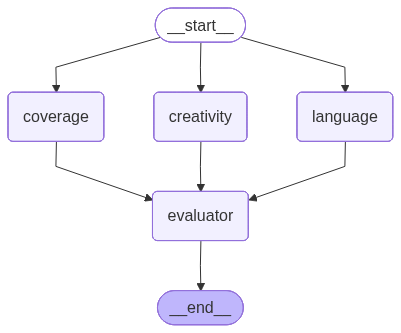

In [33]:
# Worklfow creation 
workflow = graph.compile()
workflow

In [34]:
initial_state = {
    "essay": "ChatGPT is a generative artificial intelligence chatbot developed by OpenAI. It was released in November 2022. It uses generative pre-trained transformers, such as GPT-5.2, to generate text, speech, and images in response to user prompts."
}

workflow.invoke(initial_state)

{'essay': 'ChatGPT is a generative artificial intelligence chatbot developed by OpenAI. It was released in November 2022. It uses generative pre-trained transformers, such as GPT-5.2, to generate text, speech, and images in response to user prompts.',
 'language_feedback': "The essay is clear and concise, presenting key information about ChatGPT's development and functionality. However, there are inaccuracies: ChatGPT does not use GPT-5.2 (the latest is GPT-4.5) and it cannot generate images. The explanation could also benefit from expanded details about specific applications or technical innovations.",
 'coverage_feedback': "The essay briefly mentions ChatGPT's development, release date, and underlying technology. However, it lacks depth in explaining the significance of its release, the actual GPT model (GPT-3.5 is more accurate than GPT-5.2), and its real-world applications/impact. The content is factually correct but very surface-level with minimal analysis.",
 'creativity_feedback